In [1]:
# ==============================================================
# YOLO – You Only Look Once: Echtzeit-Objekterkennung
# ==============================================================
# Lernziele:
#   - YOLO von VGG19 / InceptionV3 konzeptionell abgrenzen
#   - Bounding Boxes, Klassenbezeichnungen und Konfidenz verstehen
#   - Confidence-Threshold und NMS praktisch erproben
#   - Erkennungsgeschwindigkeit empirisch messen
# ==============================================================

!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
import time
from io import BytesIO
from google.colab import drive

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# ── Konzeptioneller Einstieg: YOLO vs. CNN-Klassifikatoren ────
#
#   VGG19 / InceptionV3:          YOLO:
#   ┌────────────────────┐        ┌────────────────────────────┐
#   │  EIN Objekt        │        │  MEHRERE Objekte           │
#   │  pro Bild          │        │  gleichzeitig              │
#   │  → Klasse          │        │  → Klasse + Position       │
#   │  → Konfidenz        │        │  → Konfidenz + Bounding Box │
#   └────────────────────┘        └────────────────────────────┘
#   Aufgabe: Klassifikation       Aufgabe: Objekterkennung (Detection)
#
# YOLO teilt das Bild in ein Gitter. Jede Zelle sagt gleichzeitig
# vorher: "Ist hier ein Objekt? Was ist es? Wo genau ist es?"
# → "You Only Look Once" = ein einziger Vorwärtsdurchlauf durch das Netz
print("Konzept geladen – Modell wird vorbereitet.")

Konzept geladen – Modell wird vorbereitet.


In [5]:
# ==============================================================
# PHASE 1: Modell laden und Modellvarianten verstehen
# ==============================================================

# ── Übersicht der YOLO11-Varianten ───────────────────────────
#
# Modell      Parameter   Geschwindigkeit   Genauigkeit (mAP)
# yolo11n.pt  ~2,6 Mio.   sehr schnell      niedrig   ← Echtzeit / Edge
# yolo11s.pt  ~9,4 Mio.   schnell           mittel
# yolo11m.pt  ~20,1 Mio.  mittel            gut
# yolo11l.pt  ~25,3 Mio.  langsamer         sehr gut
# yolo11x.pt  ~56,9 Mio.  langsam           höchste   ← Forschung / Server
#
# Für die Vorlesung: yolo11n (nano) → schnell, zeigt Echtzeit-Charakter

model = YOLO('yolo11n.pt')   # nano: ideal für Demonstrations- und Lernzwecke
print(model.info())
# ▶ Beobachten: Parameteranzahl im Vergleich zu VGG19 (~143 Mio.) und
#               InceptionV3 (~21,8 Mio.)

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
(181, 2624080, 0, 6.614336)


Mounted at /content/drive


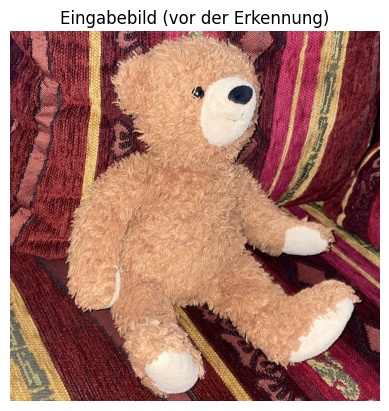

In [6]:
# ==============================================================
# PHASE 2: Eigenes Bild erkennen (Google Drive)
# ==============================================================

drive.mount('/content/drive')

import os
base_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"
file = os.path.join(base_dir, "teddy.png")   # Gleiche Aufgabe wie VGG19 / InceptionV3

image = Image.open(file)

plt.imshow(image)
plt.title("Eingabebild (vor der Erkennung)")
plt.axis("off")
plt.show()

In [7]:
# ── 2.1 Erkennung mit Standard-Threshold (conf=0.25) ─────────

start = time.time()
results = model(image, conf=0.25)   # conf = Confidence-Threshold (Standard: 0.25)
elapsed = time.time() - start

print(f"Inferenzzeit: {elapsed*1000:.1f} ms")
print(f"Erkannte Objekte: {len(results[0].boxes)}")
print()

# Ergebnisse tabellarisch ausgeben
print(f"{'Klasse':<20} {'Konfidenz':>10} {'Bounding Box (x1,y1,x2,y2)'}")
print("-" * 65)
for box in results[0].boxes:
    cls_id    = int(box.cls[0])
    cls_name  = model.names[cls_id]
    conf      = float(box.conf[0])
    coords    = box.xyxy[0].tolist()
    print(f"{cls_name:<20} {conf:>9.2%}  {[round(c,1) for c in coords]}")


0: 640x640 1 teddy bear, 1168.7ms
Speed: 101.6ms preprocess, 1168.7ms inference, 35.8ms postprocess per image at shape (1, 3, 640, 640)
Inferenzzeit: 1609.9 ms
Erkannte Objekte: 1

Klasse                Konfidenz Bounding Box (x1,y1,x2,y2)
-----------------------------------------------------------------
teddy bear              84.95%  [74.3, 3.5, 460.4, 507.6]


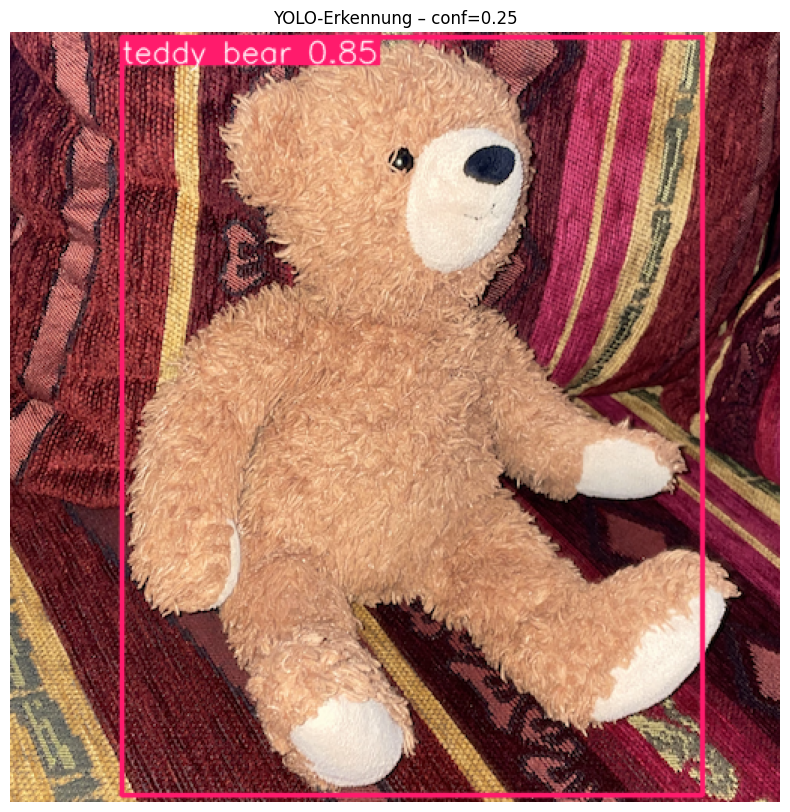

In [8]:
# ── 2.2 Visualisierung mit Bounding Boxes ────────────────────
#
# r.plot() zeichnet automatisch:
#   - Bounding Box (farbiges Rechteck)
#   - Klassenbezeichnung (Label)
#   - Konfidenzwert (z.B. "teddy bear 0.87")

for r in results:
    im_array = r.plot()
    im = Image.fromarray(im_array[..., ::-1])
    plt.figure(figsize=(10, 10))
    plt.imshow(im)
    plt.title("YOLO-Erkennung – conf=0.25")
    plt.axis("off")
    plt.show()

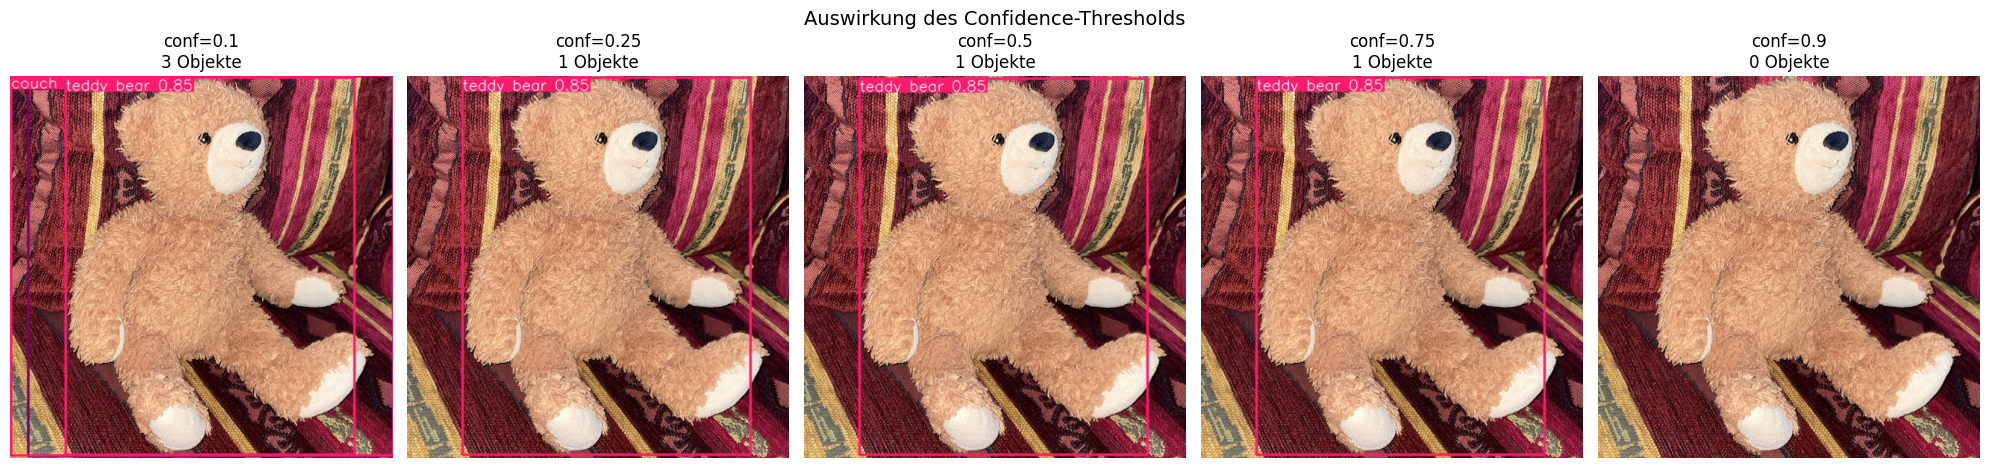

In [9]:
# ==============================================================
# PHASE 3: Confidence-Threshold experimentell erkunden
# ==============================================================
#
# Der Confidence-Threshold bestimmt, ab welcher Sicherheit ein
# erkanntes Objekt angezeigt wird.
#
#   Niedriger Threshold → mehr Erkennungen, aber mehr Fehlalarme
#   Hoher Threshold     → weniger Erkennungen, aber zuverlässiger
#
# Intern arbeitet YOLO außerdem mit Non-Maximum Suppression (NMS):
# Bei überlappenden Bounding Boxes für dasselbe Objekt wird nur
# die Box mit der höchsten Konfidenz behalten – alle anderen werden
# unterdrückt. Das verhindert Mehrfacherkennung desselben Objekts.

thresholds = [0.10, 0.25, 0.50, 0.75, 0.90]

fig, axes = plt.subplots(1, len(thresholds), figsize=(20, 5))
fig.suptitle("Auswirkung des Confidence-Thresholds", fontsize=14)

for ax, conf_val in zip(axes, thresholds):
    res = model(image, conf=conf_val, verbose=False)
    im_array = res[0].plot()
    im = Image.fromarray(im_array[..., ::-1])
    n_detected = len(res[0].boxes)
    ax.imshow(im)
    ax.set_title(f"conf={conf_val}\n{n_detected} Objekte")
    ax.axis("off")

plt.tight_layout()
plt.show()
# ▶ Beobachten: Ab welchem Threshold verschwinden echte Objekte?
#               Ab welchem Threshold tauchen Fehlalarme auf?

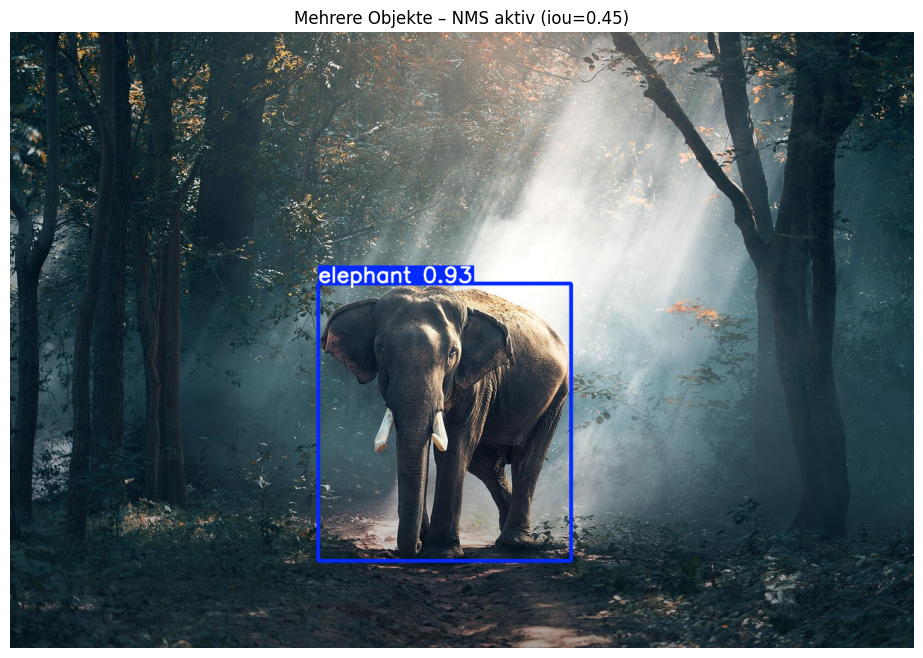

Erkannte Objekte: 1
Erkannte Objekte ohne NMS-Unterdrückung (iou=0.9): 1


In [10]:
# ==============================================================
# PHASE 4: Überlappende Objekte – NMS beobachten
# ==============================================================

# Komplexes Bild mit mehreren und möglicherweise überlappenden Objekten
url = "https://cdn.pixabay.com/photo/2016/11/14/04/45/elephant-1822636_1280.jpg"
response = requests.get(url, stream=True)
img_crowd = Image.open(BytesIO(response.content))

results_crowd = model(img_crowd, conf=0.25)

# Ergebnis anzeigen
for r in results_crowd:
    im_array = r.plot()
    im = Image.fromarray(im_array[..., ::-1])
    plt.figure(figsize=(12, 8))
    plt.imshow(im)
    plt.title("Mehrere Objekte – NMS aktiv (iou=0.45)")
    plt.axis("off")
    plt.show()

print(f"Erkannte Objekte: {len(results_crowd[0].boxes)}")

# NMS-Schwellwert manuell anpassen (iou = Intersection over Union)
# Niedriger iou-Wert → aggressivere Unterdrückung überlappender Boxes
results_no_nms = model(img_crowd, conf=0.25, iou=0.9)  # fast kein NMS
print(f"Erkannte Objekte ohne NMS-Unterdrückung (iou=0.9): {len(results_no_nms[0].boxes)}")
# ▶ Beobachten: Wie viele Mehrfach-Erkennungen entstehen ohne NMS?

In [11]:
# ==============================================================
# PHASE 5: Laufzeitmessung – Ist YOLO wirklich Echtzeit?
# ==============================================================
#
# Echtzeit bedeutet: ≥ 25 Frames pro Sekunde (FPS)
# → maximale Inferenzzeit pro Bild: 40 ms

modelle = {
    "yolo11n (nano)":  "yolo11n.pt",
    "yolo11s (small)": "yolo11s.pt",
    "yolo11m (medium)":"yolo11m.pt",
}

print(f"{'Modell':<22} {'Inferenz (ms)':>14} {'FPS':>8} {'Echtzeit?':>10}")
print("-" * 58)

for name, weights in modelle.items():
    m = YOLO(weights)
    # Warmup (erster Aufruf ist langsamer durch Initialisierung)
    m(image, verbose=False)

    # 5 Messungen mitteln für stabile Werte
    zeiten = []
    for _ in range(5):
        t0 = time.time()
        m(image, verbose=False)
        zeiten.append(time.time() - t0)

    ms  = np.mean(zeiten) * 1000
    fps = 1000 / ms
    rt  = "✓ Ja" if fps >= 25 else "✗ Nein"
    print(f"{name:<22} {ms:>13.1f}  {fps:>7.1f}  {rt:>10}")

# ▶ Erinnerung: Ergebnisse hängen stark von der Colab-GPU ab.
#   Mit GPU (T4): nano >> 25 FPS; mit CPU: möglicherweise darunter.

Modell                  Inferenz (ms)      FPS  Echtzeit?
----------------------------------------------------------
yolo11n (nano)                 209.9      4.8      ✗ Nein
yolo11s (small)                459.8      2.2      ✗ Nein
yolo11m (medium)              1558.5      0.6      ✗ Nein


In [ ]:
# ==============================================================
# BEOBACHTUNGSAUFTRÄGE (bitte schriftlich beantworten)
# ==============================================================
#
# 1. Zuverlässigkeit der Erkennung:
#    Führen Sie Phase 3 (Threshold-Vergleich) mit einem eigenen Bild aus.
#    Welche Objekte erkennt YOLO zuverlässig (conf > 0.75)?
#    Welche werden erst bei niedrigem Threshold erkannt oder gar nicht?
#    Was könnte der Grund sein?
#
# 2. Überlappende Objekte:
#    Vergleichen Sie die Ergebnisse aus Phase 4 mit iou=0.45 und iou=0.9.
#    Was ist Non-Maximum Suppression (NMS) und warum ist sie notwendig?
#    Was passiert, wenn zwei Objekte unterschiedlicher Klassen stark überlappen?
#
# 3. Erkennungsgeschwindigkeit:
#    Lesen Sie die FPS-Werte aus Phase 5 ab.
#    Ab welcher Modellgröße ist Echtzeit (≥ 25 FPS) nicht mehr gewährleistet?
#    Welchen Trade-off müssen Sie in der Praxis abwägen?
#    Vergleichen Sie: Wie lange würde VGG19 für denselben Task benötigen?